In [1]:
import os
os.environ["JAX_PLATFORMS"] = "cpu"
os.environ["CUDA_VISIBLE_DEVICES"] = "1"

import logging
import ray

ray.init(logging_level=logging.ERROR, ignore_reinit_error=True)

%load_ext autoreload
%autoreload 2

/home/n.sorokin/miniconda3/envs/verl-agent/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
2025-11-27 15:14:21,637	INFO util.py:154 -- Missing packages: ['ipywidgets']. Run `pip install -U ipywidgets`, then restart the notebook server for rich notebook output.


### model

In [2]:
from simple_agent import SimpleAgent

from craftax.craftax_classic.renderer import render_craftax_pixels as render_classic
from craftax.craftax.constants import BLOCK_PIXEL_SIZE_HUMAN
import matplotlib.pyplot as plt
import numpy as np
import time

INFO 11-27 15:14:29 [__init__.py:239] Automatically detected platform cuda.
Loading textures from cache.


(raylet) [2025-11-27 15:14:33,848 E 3165303 3165335] (raylet) file_system_monitor.cc:116: /tmp/ray/session_2025-11-27_15-14-21_674881_3164594 is over 95% full, available space: 73.4113 GB; capacity: 1511.58 GB. Object creation will fail if spilling is required.


Textures successfully loaded from cache.


In [3]:
# Пример использования SimpleAgent

# Создаем Agent
checkpoint_path = "/home/n.sorokin/verl-agent/checkpoints/verl_agent_craftext/gigpo_qwen2.5_1.5b_lora_run_20251110-160709/global_step_500"
checkpoint_path = ""

# Проверяем наличие чекпоинта и LoRA адаптера
import os
print(f"Проверка чекпоинта: {checkpoint_path}")
print(f"  Чекпоинт существует: {os.path.exists(checkpoint_path)}")

lora_path = os.path.join(checkpoint_path, "actor", "lora_adapter")
print(f"  LoRA путь: {lora_path}")
print(f"  LoRA существует: {os.path.exists(lora_path)}")

if os.path.exists(lora_path):
    adapter_files = os.listdir(lora_path)
    print(f"  LoRA файлы: {adapter_files}")

agent = SimpleAgent(
    checkpoint_path=checkpoint_path,
    base_model_path="Qwen/Qwen2-VL-2B-Instruct",
    lora_rank=64,
    lora_alpha=64,
    target_modules="all-linear",
    max_response_length=512,
    do_sample=True,  # ИСПРАВЛЕНО: должно совпадать с обучением (val_kwargs.do_sample=True)
    temperature=0.4,  # ИСПРАВЛЕНО: должно совпадать с обучением (val_kwargs.temperature=0.4)
)

# Проверяем, что LoRA загружен
print(f"\nLoRA загружен: {agent.use_lora}")
print(f"LoRA имя: {agent.lora_name}")


Проверка чекпоинта: 
  Чекпоинт существует: False
  LoRA путь: actor/lora_adapter
  LoRA существует: False
Инициализация VLM модели Qwen/Qwen2-VL-2B-Instruct...


Using a slow image processor as `use_fast` is unset and a slow processor was saved with this model. `use_fast=True` will be the default behavior in v4.52, even if the model was saved with a slow processor. This will result in minor differences in outputs. You'll still be able to use a slow processor with `use_fast=False`.
Loading checkpoint shards: 100%|██████████| 2/2 [00:01<00:00,  1.20it/s]


VLM модель загружена!
Предупреждение: LoRA адаптер не найден в 
Используется базовая модель без LoRA
SimpleAgent инициализирован!

LoRA загружен: False
LoRA имя: None


### env

In [ ]:
# Создаем простую среду (один env)
from agent_system.environments import make_envs
from omegaconf import OmegaConf, open_dict

# Создаем минимальный конфиг для среды
simple_cfg = OmegaConf.create({
    "env": {
        "env_name": "craftext/CraftextEnv",
        "craftext_settings": "achievements_collect_wood",
        "seed": 42,
        "rollout": {"n": 1},
        "max_steps": 100,
        "resources_per_worker": {  # Ресурсы для каждого env worker (обязательный параметр для make_envs)
            "num_cpus": 0.1,
            "num_gpus": 0,
        },
        "history_length": 1,
    },
    "data": {
        "val_batch_size": 1,
        "train_batch_size": 1,
    },
})

_, val_envs = make_envs(simple_cfg)

In [ ]:
print(val_envs.__dict__.keys())
print(val_envs.envs.__dict__.keys())
print(val_envs.envs._workers[0].__dict__.keys())

In [ ]:
obs, info = val_envs.reset({})

In [ ]:
state = ray.get(val_envs.envs._workers[0].get_state.remote())

In [ ]:
print(state.__dict__.keys())
print(state.env_state.__dict__.keys())
print(state.env_state.map)

In [ ]:
obs.keys()

In [ ]:
obs, info = val_envs.reset({})

state = ray.get(val_envs.envs._workers[0].get_state.remote())
pixels = render_classic(state.env_state, block_pixel_size=BLOCK_PIXEL_SIZE_HUMAN)
pixels_for_plot = np.array(pixels)
pixels_for_plot = pixels_for_plot.astype(np.uint8)

plt.imshow(pixels_for_plot)

In [ ]:
map_text = obs['anchor'][0]
print(map_text)

In [ ]:
prompt = f"""Map:
{map_text}

Agent position: (0, 0)
Target: nearest tree

Question: In which direction is the nearest tree?
Options: left, right, up, down, up-left, up-right, down-left, down-right

Answer with ONLY ONE direction word:"""

In [ ]:
action_text = agent.predict(prompt)
action_text

In [ ]:
prompt = f"""Map:
{map_text}

Agent position: (0, 0)

Question: What is the shortest sequence of actions to reach the nearest tree?
Available actions: left, right, up, down

Answer with ONLY the sequence of actions separated by commas, like: left, left, up
Answer:"""

In [ ]:
action_text = agent.predict(prompt)
action_text

In [ ]:
prompt = f"""Map:
{map_text}

Agent position: (0, 0)

Question: What are the coordinates (x, y) of the nearest tree?
Answer with ONLY the coordinates in format: x, y
Answer:"""

In [ ]:
action_text = agent.predict(prompt)
action_text

In [ ]:
prompt = f"""Map:
{map_text}

Agent position: (0, 0)

Question: How many steps (Manhattan distance) to the nearest tree?
Answer with ONLY a number:"""

In [ ]:
action_text = agent.predict(prompt)
action_text

In [ ]:
block_types = ["tree", "stone", "water", "sand", "iron", "coal", "zombie"] 
# Добавил "zombie" (или cow/skeleton), чтобы проверять динамические объекты тоже, 
# и сократил "iron ore" до "iron", так как в obs часто пишется просто материал.

# 1. EXISTENCE (Бинарная классификация)
# Проверяет, видит ли модель вообще объект.
spatial_awareness_1 = f"""Question: Is there any {{block_type}} visible in the current observation?

Answer with ONLY 'Yes' or 'No'.
Answer:"""

# 2. DISTANCE (Метрика)
# Проверяет понимание близость/дальность.
# Добавлено пояснение формулы для 1.5B моделей и обработка "not found".
spatial_awareness_2 = f"""Question: Calculate the Manhattan distance (|x| + |y|) from the agent (0, 0) to the NEAREST {{block_type}}.
If no {{block_type}} is visible, answer '-1'.

Answer with ONLY the number (integer).
Answer:"""

# 3. EXACT LOCATION (Координаты)
# Самый сложный тест для VLM, но легкий для LLM.
spatial_awareness_3 = f"""Question: Identify the coordinates (x, y) of the NEAREST {{block_type}}.
If multiple exist, choose the one with the smallest distance to (0,0).
If none exist, answer 'None'.

Answer in strict format: x, y
Answer:"""

# 4. DIRECTION (Относительное положение)
# Исправлен баг с hardcoded 'tree'.
spatial_awareness_4 = f"""Target: nearest {{block_type}}
Agent position: (0, 0)

Question: In which direction is the nearest {{block_type}} located relative to the agent?
Options: [left, right, up, down, up-left, up-right, down-left, down-right, none]

Choose 'none' if the object is not visible.
Answer with ONLY one option from the list.
Answer:"""

In [ ]:


# Пример использования функций для получения правильных ответов:
# Получаем состояние среды
obs, info = val_envs.reset({})
state = ray.get(val_envs.envs._workers[0].get_state.remote())

pixels = render_classic(state.env_state, block_pixel_size=BLOCK_PIXEL_SIZE_HUMAN)
pixels_for_plot = np.array(pixels)
pixels_for_plot = pixels_for_plot.astype(np.uint8)

plt.imshow(pixels_for_plot)

craftext_state = state.env_state  # Это и есть craftext_state

# Тестируем функции на разных типах блоков
block_types = ["tree", "stone", "water", "sand", "iron", "coal"]

print("Тестирование функций для получения правильных ответов:\n")
for block_type in block_types:
    print(f"Block type: {block_type}")
    print(f"  Existence: {answer_existence_question(craftext_state, block_type)}")
    print(f"  Distance: {answer_distance_question(craftext_state, block_type)}")
    print(f"  Coordinates: {answer_coordinates_question(craftext_state, block_type)}")
    print(f"  Direction: {answer_direction_question(craftext_state, block_type)}")
    print()


In [ ]:
dataset = collect_dataset(val_envs, num_samples=50, save_path="craftext_perception_dataset.jsonl")

### eval

In [5]:
# Импортируем функции из модулей
from craftext_answer_functions import (
    answer_existence_question,
    answer_distance_question,
    answer_coordinates_question,
    answer_direction_question,
)
from dataset_collection import collect_dataset
from model_evaluation import load_dataset, evaluate_model_on_dataset

In [6]:
dataset = load_dataset("craftext_perception_dataset.jsonl")

In [ ]:
results_1_5b = evaluate_model_on_dataset(agent, dataset, verbose=True, batch_size=32)
print(f"Qwen 2.5 1.5B Accuracy: {results_1_5b['overall_accuracy']:.2%}")

(raylet) [2025-11-27 15:47:24,755 E 3165303 3165335] (raylet) file_system_monitor.cc:116: /tmp/ray/session_2025-11-27_15-14-21_674881_3164594 is over 95% full, available space: 45.8785 GB; capacity: 1511.58 GB. Object creation will fail if spilling is required.
(raylet) [2025-11-27 15:47:34,759 E 3165303 3165335] (raylet) file_system_monitor.cc:116: /tmp/ray/session_2025-11-27_15-14-21_674881_3164594 is over 95% full, available space: 45.8897 GB; capacity: 1511.58 GB. Object creation will fail if spilling is required.
(raylet) [2025-11-27 15:47:44,764 E 3165303 3165335] (raylet) file_system_monitor.cc:116: /tmp/ray/session_2025-11-27_15-14-21_674881_3164594 is over 95% full, available space: 45.874 GB; capacity: 1511.58 GB. Object creation will fail if spilling is required.
(raylet) [2025-11-27 15:47:54,768 E 3165303 3165335] (raylet) file_system_monitor.cc:116: /tmp/ray/session_2025-11-27_15-14-21_674881_3164594 is over 95% full, available space: 45.874 GB; capacity: 1511.58 GB. Objec

In [ ]:
results_1_5b

In [1]:
# ============================================================================
# СРАВНЕНИЕ РЕЗУЛЬТАТОВ ОЦЕНКИ МОДЕЛЕЙ
# ============================================================================
# Функции для загрузки и сравнения результатов оценки моделей

import json
import os
import glob
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from collections import defaultdict

def load_evaluation_results(results_dir="evaluation_results", model_name=None):
    """
    Загружает результаты оценки из JSON файлов.
    
    Args:
        results_dir: директория с результатами
        model_name: имя модели (опционально, для фильтрации)
    
    Returns:
        Список словарей с результатами
    """
    results = []
    pattern = os.path.join(results_dir, "*.json")
    if model_name:
        pattern = os.path.join(results_dir, f"{model_name}_*.json")
    
    for filepath in glob.glob(pattern):
        with open(filepath, 'r', encoding='utf-8') as f:
            result = json.load(f)
            result['filepath'] = filepath
            results.append(result)
    
    # Сортируем по времени (из имени файла или timestamp)
    results.sort(key=lambda x: x.get('metadata', {}).get('timestamp', ''), reverse=True)
    return results


def compare_models(results_list):
    """
    Сравнивает результаты нескольких моделей.
    
    Args:
        results_list: список результатов оценки
    
    Returns:
        DataFrame с сравнением
    """
    comparison_data = []
    
    for result in results_list:
        metadata = result.get('metadata', {})
        model_name = metadata.get('model_name', 'unknown')
        
        row = {
            'Model': model_name,
            'Overall Accuracy': result.get('overall_accuracy', 0),
            'Correct': result.get('correct', 0),
            'Total': result.get('total', 0),
        }
        
        # Добавляем метрики по типам вопросов
        metrics_by_type = result.get('metrics_by_type', {})
        for qtype in ['existence', 'distance', 'coordinates', 'direction']:
            if qtype in metrics_by_type:
                row[f'{qtype.capitalize()} Accuracy'] = metrics_by_type[qtype]['accuracy']
                row[f'{qtype.capitalize()} Total'] = metrics_by_type[qtype]['total']
            else:
                row[f'{qtype.capitalize()} Accuracy'] = None
                row[f'{qtype.capitalize()} Total'] = 0
        
        # Добавляем метаданные
        row['Base Model'] = metadata.get('base_model_path', '')
        row['Checkpoint'] = metadata.get('checkpoint_path', '')
        row['LoRA Rank'] = metadata.get('lora_rank', 0)
        row['Text Observation'] = metadata.get('use_text_observation', True)
        row['Timestamp'] = metadata.get('timestamp', '')
        
        comparison_data.append(row)
    
    df = pd.DataFrame(comparison_data)
    return df


def plot_comparison(df, save_path=None):
    """
    Строит графики сравнения моделей.
    
    Args:
        df: DataFrame с результатами сравнения
        save_path: путь для сохранения графиков (опционально)
    """
    fig, axes = plt.subplots(2, 2, figsize=(15, 12))
    fig.suptitle('Сравнение моделей на датасете восприятия Craftext', fontsize=16, fontweight='bold')
    
    # 1. Общая точность
    ax1 = axes[0, 0]
    df_sorted = df.sort_values('Overall Accuracy', ascending=True)
    ax1.barh(df_sorted['Model'], df_sorted['Overall Accuracy'])
    ax1.set_xlabel('Точность')
    ax1.set_title('Общая точность')
    ax1.set_xlim(0, 1)
    for i, v in enumerate(df_sorted['Overall Accuracy']):
        ax1.text(v + 0.01, i, f'{v:.2%}', va='center')
    
    # 2. Точность по типам вопросов
    ax2 = axes[0, 1]
    question_types = ['Existence', 'Distance', 'Coordinates', 'Direction']
    x = range(len(df))
    width = 0.2
    
    for i, qtype in enumerate(question_types):
        col = f'{qtype} Accuracy'
        if col in df.columns:
            values = df[col].fillna(0)
            ax2.bar([xi + i * width for xi in x], values, width, label=qtype)
    
    ax2.set_xlabel('Модели')
    ax2.set_ylabel('Точность')
    ax2.set_title('Точность по типам вопросов')
    ax2.set_xticks([xi + width * 1.5 for xi in x])
    ax2.set_xticklabels(df['Model'], rotation=45, ha='right')
    ax2.legend()
    ax2.set_ylim(0, 1)
    
    # 3. Количество правильных ответов
    ax3 = axes[1, 0]
    df_sorted = df.sort_values('Correct', ascending=True)
    ax3.barh(df_sorted['Model'], df_sorted['Correct'], label='Правильные')
    ax3.barh(df_sorted['Model'], df_sorted['Total'] - df_sorted['Correct'], 
             left=df_sorted['Correct'], label='Неправильные', color='red', alpha=0.5)
    ax3.set_xlabel('Количество ответов')
    ax3.set_title('Распределение правильных/неправильных ответов')
    ax3.legend()
    
    # 4. Тепловая карта точности по типам вопросов
    ax4 = axes[1, 1]
    accuracy_cols = [f'{qtype} Accuracy' for qtype in question_types if f'{qtype} Accuracy' in df.columns]
    if accuracy_cols:
        heatmap_data = df.set_index('Model')[accuracy_cols].fillna(0)
        sns.heatmap(heatmap_data, annot=True, fmt='.2%', cmap='YlOrRd', ax=ax4, cbar_kws={'label': 'Точность'})
        ax4.set_title('Точность по типам вопросов (тепловая карта)')
        ax4.set_ylabel('')
    
    plt.tight_layout()
    
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
        print(f"График сохранен в: {save_path}")
    
    plt.show()


def analyze_errors(results_list, dataset_path=None):
    """
    Анализирует ошибки моделей.
    
    Args:
        results_list: список результатов оценки
        dataset_path: путь к датасету (для детального анализа)
    
    Returns:
        DataFrame с анализом ошибок
    """
    error_analysis = []
    
    for result in results_list:
        model_name = result.get('metadata', {}).get('model_name', 'unknown')
        results_data = result.get('results', [])
        
        # Группируем ошибки по типам вопросов и блокам
        errors_by_type = defaultdict(lambda: {'total': 0, 'errors': 0})
        errors_by_block = defaultdict(lambda: {'total': 0, 'errors': 0})
        
        for r in results_data:
            qtype = r['question_type']
            block_type = r['block_type']
            is_correct = r['is_correct']
            
            errors_by_type[qtype]['total'] += 1
            errors_by_block[block_type]['total'] += 1
            
            if not is_correct:
                errors_by_type[qtype]['errors'] += 1
                errors_by_block[block_type]['errors'] += 1
        
        # Формируем данные для анализа
        for qtype, stats in errors_by_type.items():
            error_analysis.append({
                'Model': model_name,
                'Type': 'Question Type',
                'Category': qtype,
                'Total': stats['total'],
                'Errors': stats['errors'],
                'Error Rate': stats['errors'] / stats['total'] if stats['total'] > 0 else 0
            })
        
        for block_type, stats in errors_by_block.items():
            error_analysis.append({
                'Model': model_name,
                'Type': 'Block Type',
                'Category': block_type,
                'Total': stats['total'],
                'Errors': stats['errors'],
                'Error Rate': stats['errors'] / stats['total'] if stats['total'] > 0 else 0
            })
    
    return pd.DataFrame(error_analysis)


def print_detailed_comparison(df):
    """
    Выводит детальное сравнение моделей в консоль.
    
    Args:
        df: DataFrame с результатами сравнения
    """
    print("=" * 100)
    print("ДЕТАЛЬНОЕ СРАВНЕНИЕ МОДЕЛЕЙ")
    print("=" * 100)
    
    print("\n📊 ОБЩИЕ МЕТРИКИ:")
    print(df[['Model', 'Overall Accuracy', 'Correct', 'Total']].to_string(index=False))
    
    print("\n📈 ТОЧНОСТЬ ПО ТИПАМ ВОПРОСОВ:")
    accuracy_cols = [col for col in df.columns if 'Accuracy' in col and 'Overall' not in col]
    print(df[['Model'] + accuracy_cols].to_string(index=False))
    
    print("\n🔧 КОНФИГУРАЦИЯ МОДЕЛЕЙ:")
    config_cols = ['Model', 'Base Model', 'Checkpoint', 'LoRA Rank', 'Text Observation']
    print(df[config_cols].to_string(index=False))
    
    print("\n" + "=" * 100)


# Пример использования:
# 
# # 1. Загружаем результаты всех моделей
# results = load_evaluation_results("evaluation_results")
# 
# # 2. Сравниваем модели
# comparison_df = compare_models(results)
# 
# # 3. Выводим детальное сравнение
# print_detailed_comparison(comparison_df)
# 
# # 4. Строим графики
# plot_comparison(comparison_df, save_path="model_comparison.png")
# 
# # 5. Анализируем ошибки
# error_df = analyze_errors(results)
# print("\nАнализ ошибок:")
# print(error_df.groupby(['Model', 'Type', 'Category']).agg({
#     'Error Rate': 'mean',
#     'Errors': 'sum',
#     'Total': 'sum'
# }).to_string())


ДЕТАЛЬНОЕ СРАВНЕНИЕ МОДЕЛЕЙ

📊 ОБЩИЕ МЕТРИКИ:
       Model  Overall Accuracy  Correct  Total
  qwen2.5_7b          0.379286      531   1400
qwen2.5_1.5b          0.301429      422   1400
 qwen2_vl_2b          0.233571      327   1400

📈 ТОЧНОСТЬ ПО ТИПАМ ВОПРОСОВ:
       Model  Existence Accuracy  Distance Accuracy  Coordinates Accuracy  Direction Accuracy
  qwen2.5_7b            0.868571           0.508571              0.060000            0.080000
qwen2.5_1.5b            0.594286           0.345714              0.060000            0.205714
 qwen2_vl_2b            0.874286           0.057143              0.002857            0.000000

🔧 КОНФИГУРАЦИЯ МОДЕЛЕЙ:
       Model                 Base Model Checkpoint  LoRA Rank  Text Observation
  qwen2.5_7b   Qwen/Qwen2.5-7B-Instruct                     0              True
qwen2.5_1.5b Qwen/Qwen2.5-1.5B-Instruct                     0              True
 qwen2_vl_2b  Qwen/Qwen2-VL-2B-Instruct                     0             False

График сохран

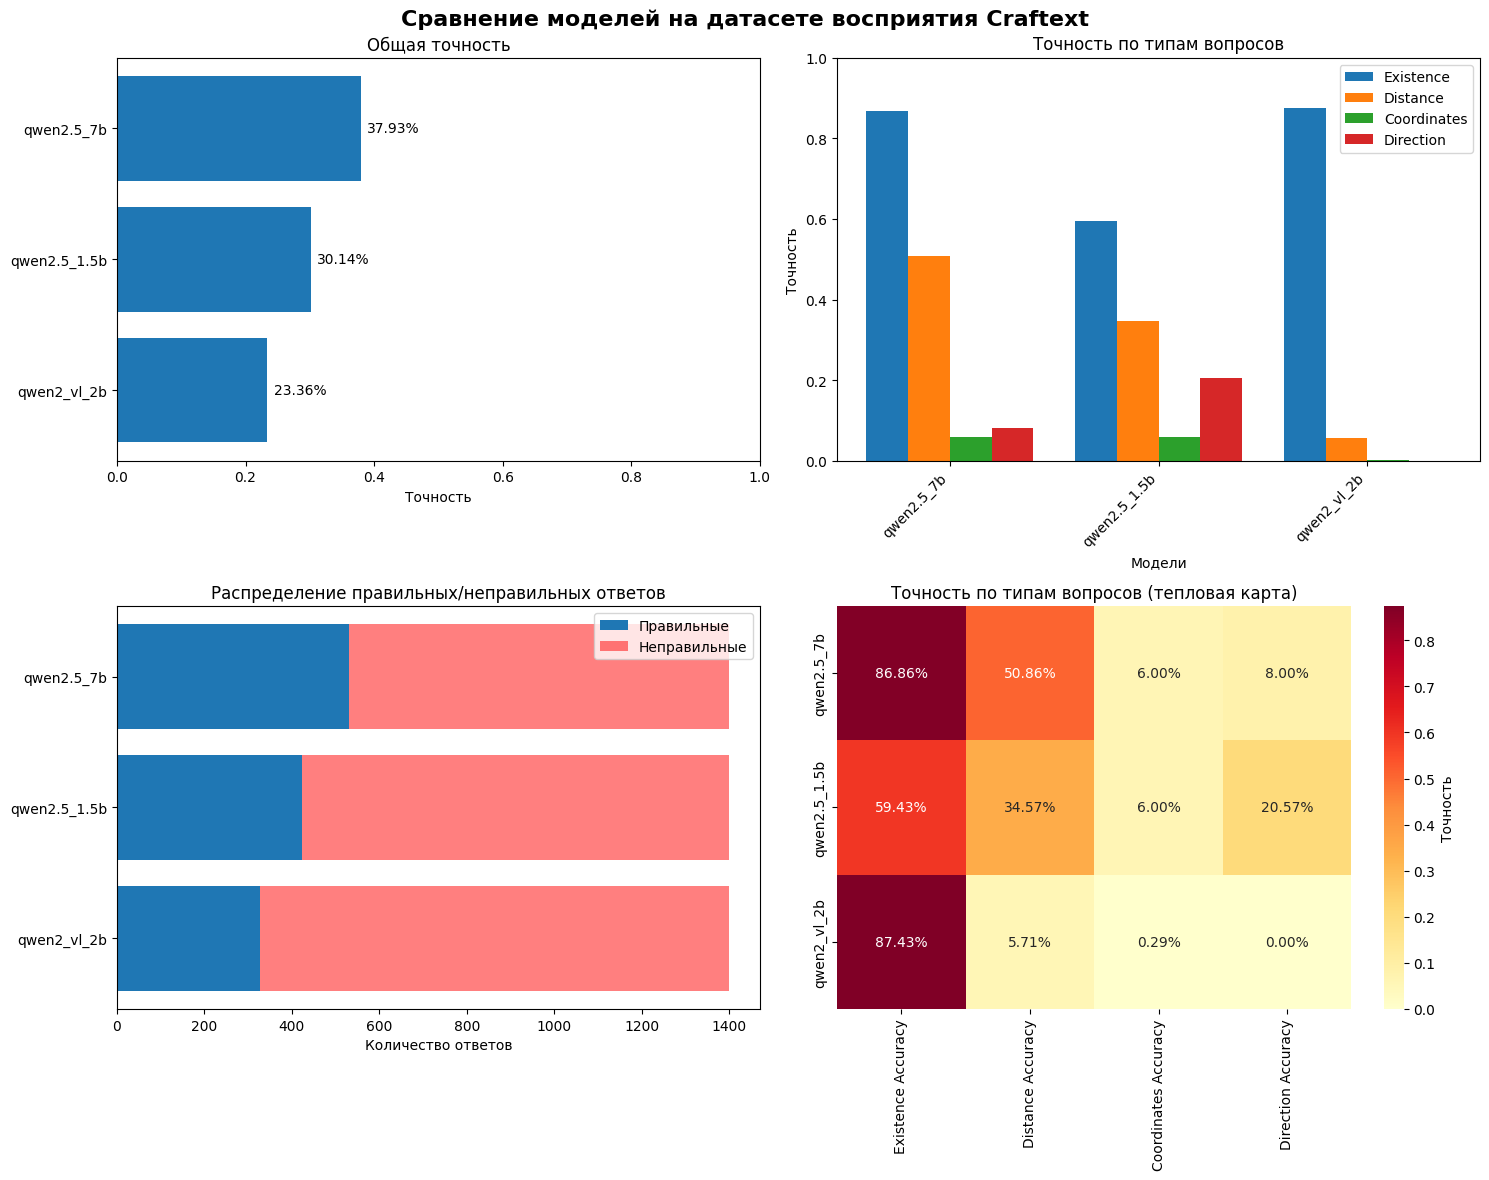


Анализ ошибок:
                                        Error Rate  Errors  Total
Model        Type          Category                              
qwen2.5_1.5b Block Type    coal           0.665000     133    200
                           iron           0.595000     119    200
                           sand           0.770000     154    200
                           stone          0.810000     162    200
                           tree           0.740000     148    200
                           water          0.745000     149    200
                           zombie         0.565000     113    200
             Question Type coordinates    0.940000     329    350
                           direction      0.794286     278    350
                           distance       0.654286     229    350
                           existence      0.405714     142    350
qwen2.5_7b   Block Type    coal           0.565000     113    200
                           iron           0.555000     111  

In [2]:
# 1. Загружаем результаты всех моделей
results = load_evaluation_results("evaluation_results")

# 2. Сравниваем модели
comparison_df = compare_models(results)

# 3. Выводим детальное сравнение
print_detailed_comparison(comparison_df)

# 4. Строим графики
plot_comparison(comparison_df, save_path="model_comparison.png")

# 5. Анализируем ошибки
error_df = analyze_errors(results)
print("\nАнализ ошибок:")
print(error_df.groupby(['Model', 'Type', 'Category']).agg({
    'Error Rate': 'mean',
    'Errors': 'sum',
    'Total': 'sum'
}).to_string())